# Two leaks that look nothing like leaking

Lesson 1 broke the training/test independence in the most visible way it can
break: selecting features on the whole dataset before splitting. This notebook
implements handout Section 9 and breaks it in the two ways that actually show
up in real projects — **imputing** a missing value and **encoding** a category —
because both of those steps *learn from data* exactly as scaling does, and
almost nobody thinks of them as "training a model." Nothing here raises an
error. Nothing looks wrong in the code. That is the point.


## 1. Setup

In [1]:
# Everything used here ships with the course image:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

from churn_data import LOW_CARD_CATEGORICAL, NUMERIC_FEATURES, TARGET, make_churn_data

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)

df = make_churn_data(n=2000, seed=RANDOM_STATE)
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
train_idx, test_idx = X_train.index, X_test.index
print(f"train: {len(X_train)}   test: {len(X_test)}")


train: 1500   test: 500


## 2. Leak 1 — imputing a missing value using the whole dataset

`age` is missing for about 8% of customers. `KNNImputer` and its relatives fill
a gap using the *values of other rows* — nearest neighbours in feature space.
That is exactly what makes it dangerous to fit before splitting: "nearest
neighbours in the whole dataset" includes neighbours that belong to the test
set. A training row's missing age can end up filled in using information from
a row you are about to pretend you never saw.

We build the neighbour search ourselves, with `NearestNeighbors`, so we can
point at the exact rows responsible — a diagnostic no metric will hand you.


In [2]:
search_features = ["tenure_months", "monthly_charges", "num_support_calls"]
filled = df[search_features].fillna(df[search_features].median())
scaler = StandardScaler().fit(filled)          # fitted on ALL rows — the bug
Z = scaler.transform(filled)

nn = NearestNeighbors(n_neighbors=6).fit(Z)     # fitted on ALL rows — the bug

missing_age_train = X_train[X_train["age"].isna()].index
print(f"{len(missing_age_train)} training rows have a missing age")

leaked_rows = []
for row_id in missing_age_train:
    pos = df.index.get_loc(row_id)
    _, neighbours = nn.kneighbors(Z[pos].reshape(1, -1))
    neighbours = df.index[neighbours[0]]
    neighbours = neighbours[neighbours != row_id][:5]
    test_neighbours = [n for n in neighbours if n in test_idx]
    if test_neighbours:
        leaked_rows.append((row_id, test_neighbours))

print(f"{len(leaked_rows)} / {len(missing_age_train)} of those rows had at least one "
      f"TEST-set row among the neighbours used to fill their age")
print("example — training row", leaked_rows[0][0], "was imputed partly from test row(s)", leaked_rows[0][1])


128 training rows have a missing age
98 / 128 of those rows had at least one TEST-set row among the neighbours used to fill their age
example — training row 1922 was imputed partly from test row(s) [1127]


That number — most of the affected training rows — is the smoking gun. Nothing
crashed. `KNNImputer` did exactly what it is documented to do. The bug is
entirely in the order of operations: the neighbour search was fitted before
the split existed.

Now measure what it actually costs downstream: impute **all** the numeric
columns with `KNNImputer`, once leakily (fitted on the train/test
concatenation) and once honestly (fitted on `X_train` alone, as it would be
inside a `Pipeline`), and compare the same logistic regression trained on
each.


In [3]:
from sklearn.impute import KNNImputer

# LEAKY: the imputer sees every row, including the test rows, before the split
# "happens" from its point of view.
combined = pd.concat([X_train, X_test])
imputed_values = KNNImputer(n_neighbors=5).fit_transform(combined[NUMERIC_FEATURES])
combined_imputed = combined.copy()
combined_imputed[NUMERIC_FEATURES] = imputed_values
X_train_leaky = combined_imputed.loc[X_train.index]
X_test_leaky = combined_imputed.loc[X_test.index]

pre_leaky = ColumnTransformer([
    ("numeric", StandardScaler(), NUMERIC_FEATURES),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]),
     LOW_CARD_CATEGORICAL),
])
model_leaky_impute = Pipeline([("preprocess", pre_leaky), ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
model_leaky_impute.fit(X_train_leaky, y_train)
auc_leaky_impute = roc_auc_score(y_test, model_leaky_impute.predict_proba(X_test_leaky)[:, 1])

# HONEST: the imputer sits inside the pipeline, so .fit() only ever sees X_train.
pre_honest_impute = ColumnTransformer([
    ("numeric", Pipeline([("impute", KNNImputer(n_neighbors=5)), ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]),
     LOW_CARD_CATEGORICAL),
])
model_honest_impute = Pipeline([("preprocess", pre_honest_impute), ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
model_honest_impute.fit(X_train, y_train)
auc_honest_impute = roc_auc_score(y_test, model_honest_impute.predict_proba(X_test)[:, 1])

print(f"leaky imputation  AUC: {auc_leaky_impute:.4f}")
print(f"honest imputation AUC: {auc_honest_impute:.4f}")


leaky imputation  AUC: 0.7547
honest imputation AUC: 0.7530


> **Try this:** the gap is small — a handful of contaminated values in one
> feature rarely swings a whole model. That is worth sitting with rather than
> dismissing: a leak does not have to be dramatic to be wrong, and it is still
> an optimistic number reported to whoever reads it next. Raise the missing-completely-at-random (MCAR)
> fraction for `age` in `churn_data.py` from `0.08` towards `0.30` and rerun
> this notebook — more contaminated rows should widen the gap.


## 3. Leak 2 — encoding a category using the whole dataset

`zip_code` has 493 distinct values across 2000 customers — about four per code,
and one code in eleven seen only once. Notebook 1's correlation heatmap showed
it carries essentially no signal, by construction: churn here does not depend
on zip code at all. Watch what happens when we encode it anyway, the way it
often gets done in practice: replace each code with the average churn rate of
customers who share it, computed once, before anybody has split anything.


In [4]:
full_means = df.groupby("zip_code")[TARGET].mean()
df_leaky = df.copy()
df_leaky["zip_encoded"] = df_leaky["zip_code"].map(full_means)

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    df_leaky.drop(columns=[TARGET, "zip_code"]), y,
    test_size=0.25, random_state=RANDOM_STATE, stratify=y,
)

leaky_numeric = NUMERIC_FEATURES + ["zip_encoded"]
leaky_pre = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), leaky_numeric),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), LOW_CARD_CATEGORICAL),
])
model_leaky = Pipeline([("preprocess", leaky_pre), ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
model_leaky.fit(Xl_train, yl_train)
proba_leaky = model_leaky.predict_proba(Xl_test)[:, 1]

print(f"LEAKY  (zip_code encoded before the split)")
print(f"  accuracy: {accuracy_score(yl_test, model_leaky.predict(Xl_test)):.3f}")
print(f"  AUC:      {roc_auc_score(yl_test, proba_leaky):.3f}")


LEAKY  (zip_code encoded before the split)
  accuracy: 0.846
  AUC:      0.891


Compare that against a model that treats `zip_code` honestly: `sklearn`'s own
`TargetEncoder` cross-fits internally, computing each training row's encoded
value from the *other* training folds, never from the row's own label — the
library version of the leave-one-out idea in Section 9.2 of the handout.


In [5]:
honest_pre = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), LOW_CARD_CATEGORICAL),
    ("zip", TargetEncoder(target_type="binary"), ["zip_code"]),
])
model_honest = Pipeline([("preprocess", honest_pre), ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
model_honest.fit(X_train, y_train)
proba_honest = model_honest.predict_proba(X_test)[:, 1]

print(f"HONEST (TargetEncoder, cross-fitted inside the pipeline)")
print(f"  accuracy: {accuracy_score(y_test, model_honest.predict(X_test)):.3f}")
print(f"  AUC:      {roc_auc_score(y_test, proba_honest):.3f}")
print()
print(f"For comparison, notebook 2's model without zip_code at all reached AUC ~0.751 —")
print(f"the honest number here should land close to that, because zip_code has nothing to add.")


HONEST (TargetEncoder, cross-fitted inside the pipeline)
  accuracy: 0.820
  AUC:      0.751

For comparison, notebook 2's model without zip_code at all reached AUC ~0.751 —
the honest number here should land close to that, because zip_code has nothing to add.


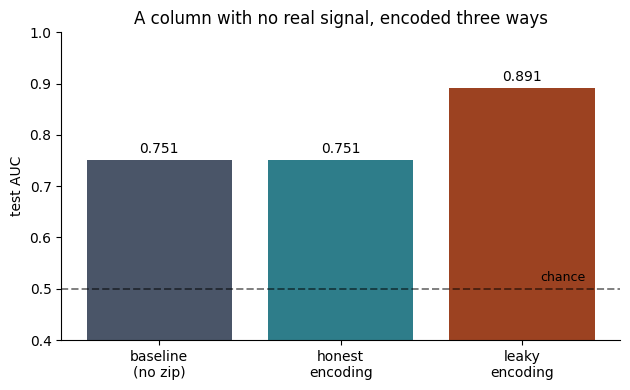

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["baseline\n(no zip)", "honest\nencoding", "leaky\nencoding"]
aucs = [0.751, roc_auc_score(y_test, proba_honest), roc_auc_score(yl_test, proba_leaky)]
colours = ["#4A5568", "#2E7D8A", "#9C4221"]
bars = ax.bar(labels, aucs, color=colours)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axhline(0.5, ls="--", lw=1.4, color="black", alpha=.5)
ax.text(2.35, 0.515, "chance", fontsize=9, ha="right")
ax.set_ylabel("test AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("A column with no real signal, encoded three ways")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "target_encoding_leak.png", dpi=150, bbox_inches="tight")
plt.show()


The leaky version looks like a meaningfully better model. It is not one: the
column it is built on carries no information about churn by construction. What
it carries is a smuggled copy of the label, delivered through group means that
are too small to hide it.

## 4. Why small groups are what makes it dangerous

Handout Section 9.2 derives this exactly: for a category with $n_c$ members,
encoding a row with its own group's mean (the leaky version) differs from
encoding it with the *other* members' mean (the honest, leave-one-out version)
by

$$\bar{y}_c - \bar{y}_c^{(-i)} = \frac{y_i - \bar{y}_c^{(-i)}}{n_c}$$

— a gap that shrinks as $1/n_c$. For $n_c = 1$ it is not a small bias at all:
the "encoded feature" simply **is** the label.


In [7]:
zip_counts = df["zip_code"].value_counts()
singleton_zips = zip_counts[zip_counts == 1].index
example_zip = singleton_zips[0]
example_row = df[df["zip_code"] == example_zip].iloc[0]
print(f"zip code {example_zip!r} has exactly one customer.")
print(f"their churn label: {example_row[TARGET]}")
print(f"the leaky encoded feature for that same customer: {full_means[example_zip]:.3f}")
print("— identical. The feature does not predict the label; for this row, it IS the label.")


zip code 'Z472' has exactly one customer.
their churn label: 0
the leaky encoded feature for that same customer: 0.000
— identical. The feature does not predict the label; for this row, it IS the label.


## 5. The rule, restated for preprocessing

Everything that **learns anything from data** — a mean, a set of neighbours, a
per-category target average — belongs inside the fold it is fitted on, and
that includes imputation and encoding just as much as it includes scaling.
`ColumnTransformer` inside `Pipeline`, from notebook 2, is not a style
preference: it is the structural guarantee that makes both leaks in this
notebook impossible by construction, because `.fit()` is only ever called on
`X_train`.


## Summary

- Fitting a `KNNImputer` before splitting lets test-set rows act as neighbours
  for training-set imputations — traceable directly, row by row, and it
  happened to most of the affected rows in this dataset.
- Encoding a high-cardinality categorical by its target mean, computed before
  the split, manufactured an area under the receiver operating characteristic curve
(AUC) of roughly 0.89 out of a column with no real
  signal — the same shape of illusion as Lesson 1's 77% on coin-flip labels,
  produced by an ordinary-looking two-line preprocessing step instead of an
  obviously wrong one.
- The size of that illusion is not arbitrary: it shrinks as $1/n_c$ with group
  size, and hits its worst case — the feature equals the label exactly — for
  categories seen only once.
- The fix is the same fix as every leak in this course: nothing is fitted
  outside the training fold, enforced by putting every learning step,
  including imputers and encoders, inside the pipeline.
